# LS-PIE Explanation
This notebook explains the basic application of the LS-PIE module on a simple example problem

## Creating Example Problem


In [8]:
import numpy as np
import matplotlib.pyplot as plt

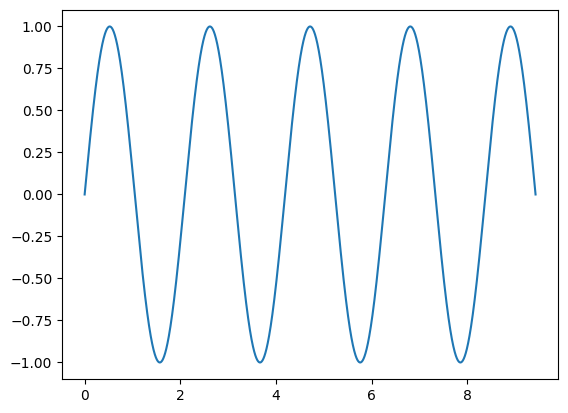

In [9]:
n = 4000
end = 3*np.pi
window = 30
randNumb = 500

x = np.linspace(0, end, n)
y = np.sin(2*x+x)

plt.plot(x,y)

signal = y

### Hankelize

In [10]:
from functions import hankelize , inverseHankelize

In [11]:
L=500
B = hankelize(signal,L)
np.shape(B)

(500, 3501)

In [12]:
from sklearn.decomposition import PCA, FastICA
n_components = 5

model1 = PCA(n_components =n_components)
PCs = model1.fit_transform(B).T

model2 = FastICA(n_components =n_components )
ICs = model2.fit_transform(B).T

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


Text(0.5, 1.0, 'Plot of ICs')

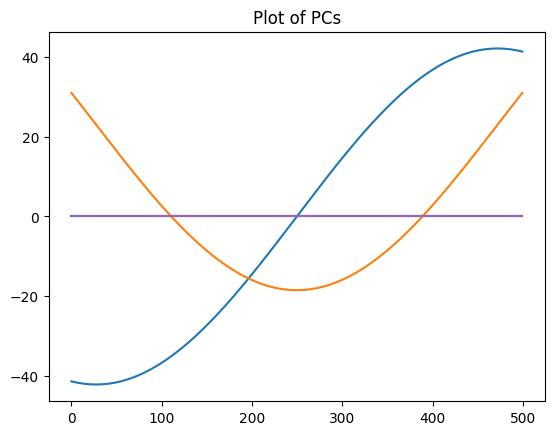

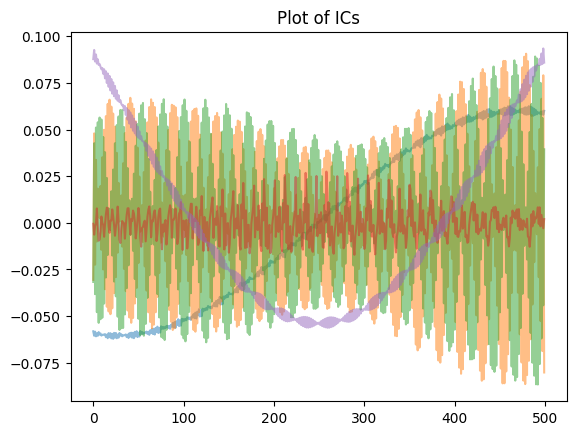

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(PCs.T)
plt.title("Plot of PCs")

plt.figure()
plt.plot(ICs.T, alpha = 0.5)
plt.title("Plot of ICs")

# The Module

## LS-PIE Processor

In addition to implementation of each of these approaches as individual modules we combine all of them into a single LS-PIE processor. This class requires: [data,method,latentModel,inputs, hank], where the data is the input signal, the method is one of the five approaches listed below, the latent model is the method to decompose the input signal, the inputs are extra information depending on the approach, and finally Hankelization indicates whether the input needs to be transformed before processing. 
The additional inputs for each module are as follows:

- LR \& LS:
    - Required inputs: [ncomp,metric]
    - Where "ncomp" is the number of components to solve for, and "metric" is a scoring function that generates the scores used to Rank and Sort the outputs.

- LC:
    - Required inputs [ncomp,metric,cmodel,ccomp]
    - Where "ncomp" is the number of latent components to solve for,  "metric" is a scoring function that generates the scores used to cluster the outputs, "cmodel" is the function that clusters the components according to the scores, and "ccomp" is the final number of compressed components.
- LCON:
    - Required inputs: [ncomp,metric,cmodel]
    - Where "ncomp" is the number of latent components to solve for,  "metric" is a scoring function that generates the scores used to cluster the outputs, and "cmodel" is the function that clusters the components according to the scores.
- LEXP: 
    - Required inputs:[cmodel,metric,cutoff,maxit]
    - Where "cmodel" is the function that clusters the components according to the scores,  "metric" is a scoring function that generates the scores used to rank the outputs, "cutoff" is the required minimum score needed to return components, and "maxit" is the maximum number of iterations to be solved.




### Ranking Example:


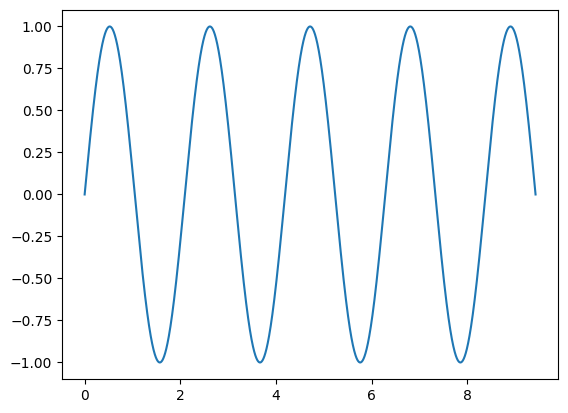

In [14]:
import numpy as np
import matplotlib.pyplot as plt
n = 4000
end = 3*np.pi
window = 30
randNumb = 500

x = np.linspace(0, end, n)
y = np.sin(2*x+x)

plt.plot(x,y)

signal = y


In [15]:
from methods import ranker
from functions import prebuiltICA, innerProduct

from functions import hankelize
hank = 2000
X = hankelize(signal,hank)

components = prebuiltICA(X, 5)
print(np.shape(components))

fitModel = ranker(components,X,innerProduct)

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


(5, 2000)


Text(0.5, 1.0, 'Ranked Components')

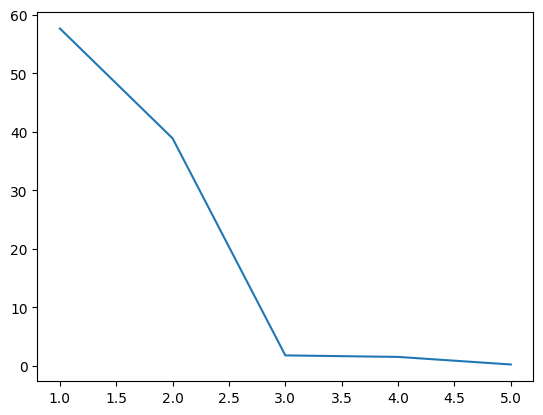

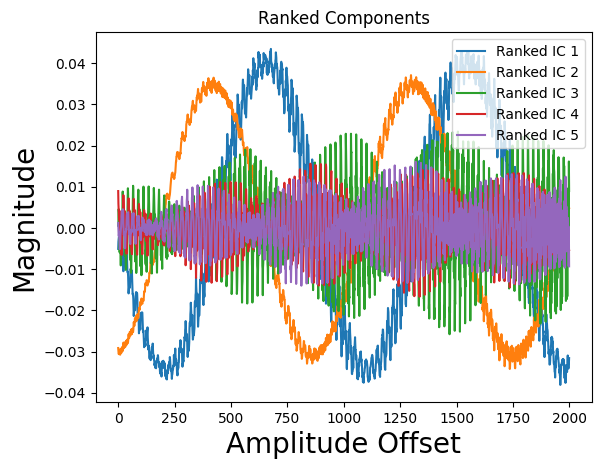

In [16]:
rankedScores = fitModel.scores
rankedComponents = fitModel.outComponents
plt.figure()
plt.plot(range(1,len(rankedScores)+1),rankedScores)

txtsize = 20
plt.figure()
for i in range(n_components):
    plt.plot(rankedComponents[i], label = "Ranked IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Ranked Components")

In [18]:
from functions import prebuiltICA, innerProduct
from processor import processor
# ranking processor:
inputs = [5,innerProduct]

rankPro = processor(signal,"LR",prebuiltICA,inputs,2500)


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


Text(0.5, 1.0, 'Ranked Components')

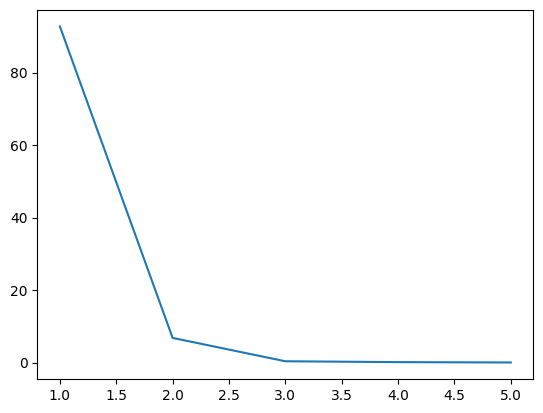

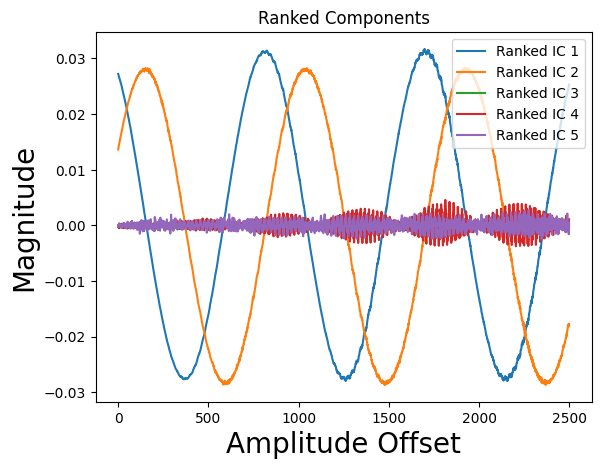

In [19]:
rankedScores = rankPro.scores
rankedComponents = rankPro.outs
plt.figure()
plt.plot(range(1,len(rankedScores)+1),rankedScores)

txtsize = 20
plt.figure()
for i in range(n_components):
    plt.plot(rankedComponents[i], label = "Ranked IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Ranked Components")

### Scaling Example

In [20]:
from functions import prebuiltICA, innerProduct
from processor import processor
# ranking processor:
inputs = [5,innerProduct]

scalePro = processor(signal,"LS",prebuiltICA,inputs,2500)


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


Text(0.5, 1.0, 'Scaled Components')

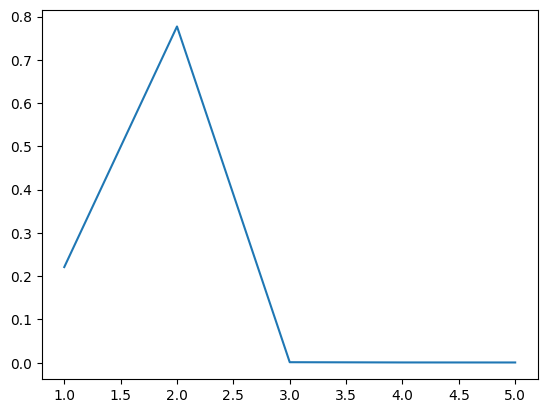

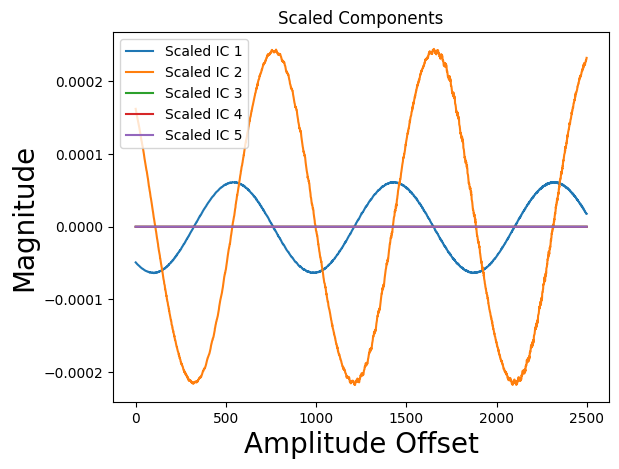

In [21]:
scaledScores = scalePro.scores
scaledComponents = scalePro.outs
plt.figure()
plt.plot(range(1,len(scaledScores)+1),scaledScores)

txtsize = 20
plt.figure()
for i in range(n_components):
    plt.plot(scaledComponents[i], label = "Scaled IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Scaled Components")

### Clustering Example

In [22]:
from methods import ranker, clustering
from functions import prebuiltICA, innerProduct

from functions import hankelize
hank = 2000
X = hankelize(signal,hank)

components = prebuiltICA(X, 7)
print(np.shape(components))

fitModel = clustering(components,X,4)

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


(7, 2000)


Text(0.5, 1.0, 'Clustered Components')

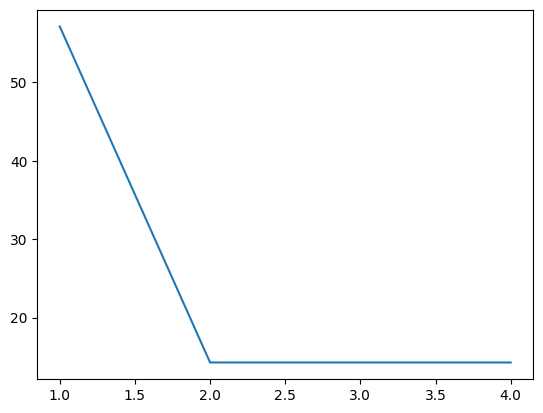

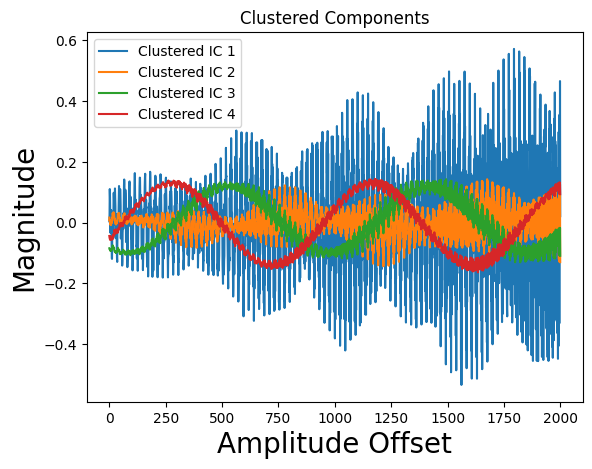

In [23]:
scaledScores = fitModel.scores
scaledComponents = fitModel.outComponents
plt.figure()
plt.plot(range(1,len(scaledScores)+1),scaledScores)

txtsize = 20
plt.figure()
for i in range(len(scaledScores)):
    plt.plot(scaledComponents[i], label = "Clustered IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Clustered Components")

In [24]:
from functions import prebuiltICA, innerProduct
from processor import processor

from sklearn.cluster import Birch 
# clustering processor:
tcomp = 10
ncomp = 3
inputs = [tcomp,None,None,ncomp]

clustPro = processor(signal,"LC",prebuiltICA,inputs,2500)


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


Text(0.5, 1.0, 'Clustered Components')

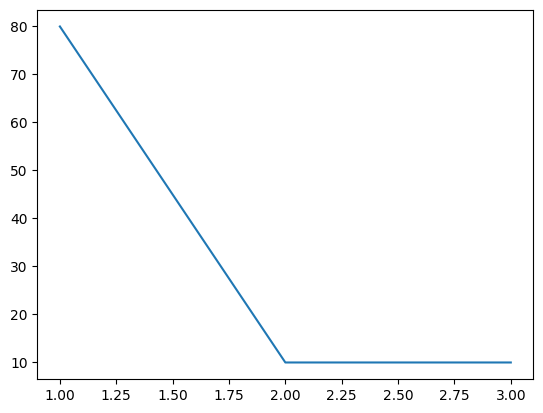

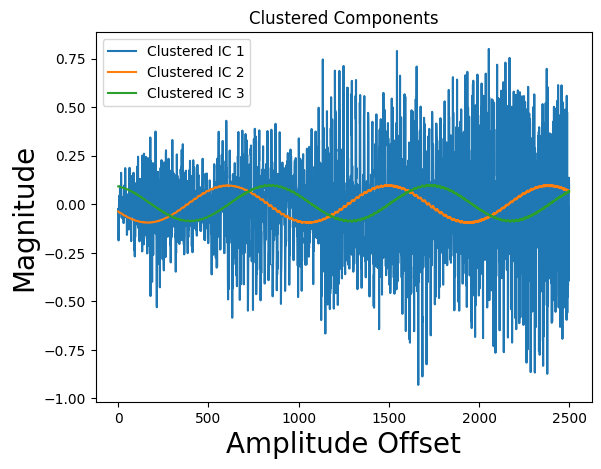

In [25]:
clustScores = clustPro.scores
clustComponents = clustPro.outs
plt.figure()
plt.plot(range(1,len(clustScores)+1),clustScores)

txtsize = 20
plt.figure()
for i in range(ncomp):
    plt.plot(clustComponents[i], label = "Clustered IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Clustered Components")

# LCON and LEXP

### LCON Example

In [26]:
from sklearn.cluster import Birch ,DBSCAN,OPTICS  # type: ignore
import numpy as np
import methods
from functions import hankelize,prebuiltICA,innerProducts
n = 4000
end = 3*np.pi

x = np.linspace(0, end, n)
y = np.sin(2*x+x)
signal = y

hank = 2000
X = hankelize(signal,hank)

components = prebuiltICA(X, 5)
print(np.shape(components))
signal = X[:,:-1]

clusteringModel = OPTICS(min_samples=1)
metric = innerProducts

clust = methods.condensing(components,signal,clusteringModel = clusteringModel, metric = metric)

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


(5, 2000)


Text(0.5, 1.0, 'Clustered Components')

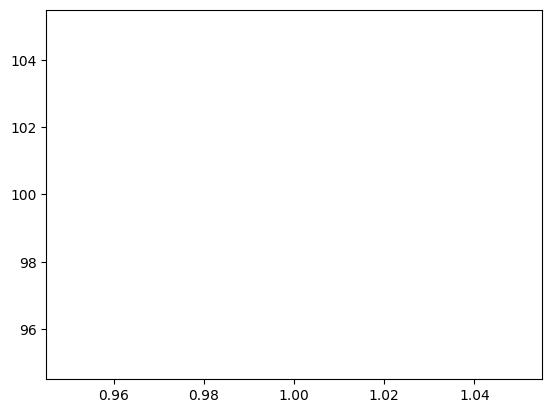

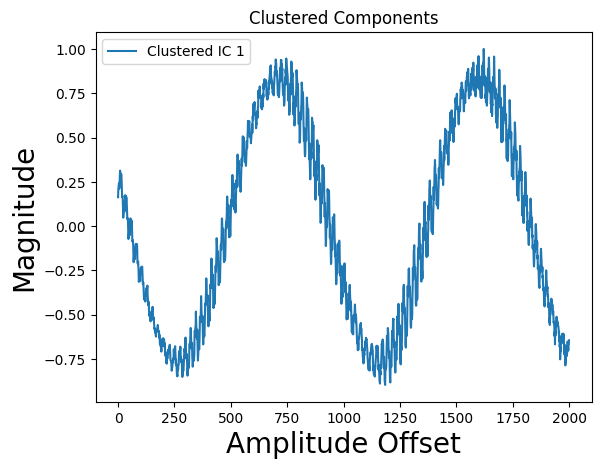

In [27]:
import matplotlib.pyplot as plt

clustScores = clust.scores
clustComponents = clust.outComponents
plt.figure()
plt.plot(range(1,len(clustScores)+1),clustScores)

txtsize = 20
plt.figure()
for i in range(len(clustScores)):
    plt.plot(clustComponents[i], label = "Clustered IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Clustered Components")

In [28]:
from processor import processor
n = 4000
end = 3*np.pi

x = np.linspace(0, end, n)
y = np.sin(2*x+x)
signal = y

inputs = [5,innerProducts,OPTICS(min_samples=1)]

condPro = processor(signal,"LCON",prebuiltICA,inputs,2500)

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


Text(0.5, 1.0, 'Clustered Components')

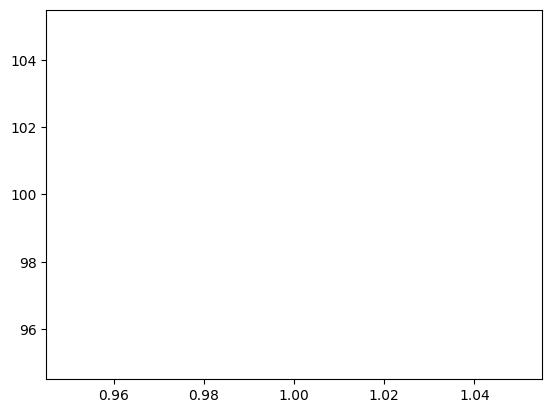

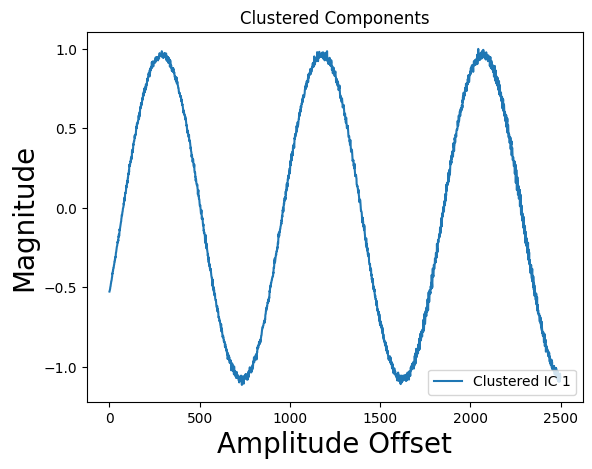

In [29]:
condScores = condPro.scores
condComponents = condPro.outs
plt.figure()
plt.plot(range(1,len(condScores)+1),condScores)

txtsize = 20
plt.figure()
for i in range(len(condScores)):
    plt.plot(condComponents[i], label = "Clustered IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("Clustered Components")

## LEXP Example

In [30]:
def expDot(X,components):
    import numpy as np
    return np.sum(np.abs(np.dot(components,X)),axis = 1)


def norm2(X):
    import numpy as np
    tot = np.sum(X)
    return X/tot

def nonCluster(X):
    return X

In [31]:
from methods import LEXP
from functions import hankelize, prebuiltICA,nonCluster,expDot
import numpy as np

n = 4000
end = 3*np.pi

x = np.linspace(0, end, n)
y = np.sin(2*x+x)
signal = y



hank = 2000
X = hankelize(signal,hank)
clusteringModel = nonCluster
LVM = prebuiltICA
metric = expDot
cutoff = 0.1
minScore = 10
maxit = 10
n_components = 2

lexp = LEXP(X,LVM,clusteringModel,metric,cutoff,maxit)

c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


[41341.18652737 39031.85363973]
[0.51436634 0.48563366]
0.48563365972691896


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


[  285.09314778 37193.95610746 43327.56858012]
[0.00352809 0.46028354 0.53618837]
0.0035280915773739435


Text(0.5, 1.0, 'LEXP Components')

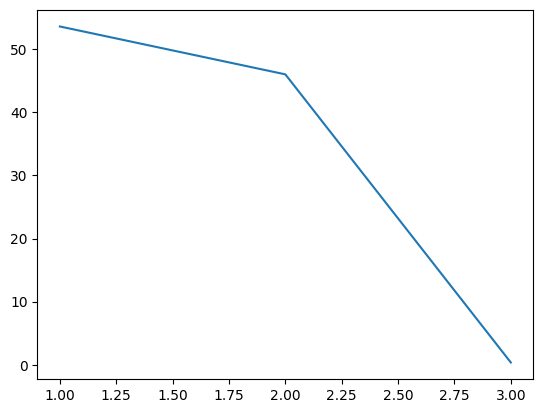

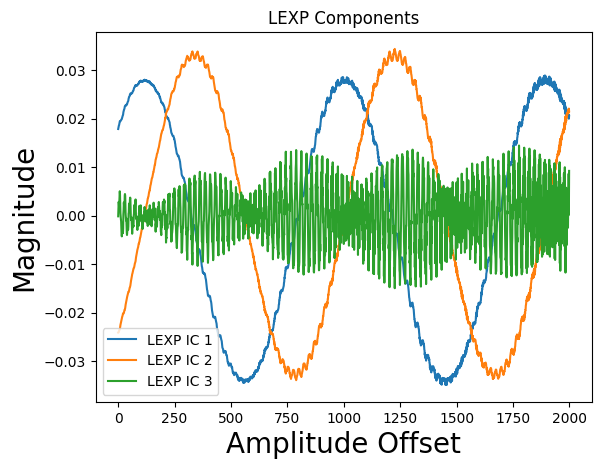

In [32]:
import matplotlib.pyplot as plt

clustScores = lexp.scores
clustComponents = lexp.outComponents
plt.figure()
plt.plot(range(1,len(clustScores)+1),clustScores)

txtsize = 20
plt.figure()
for i in range(len(clustScores)):
    plt.plot(clustComponents[i], label = "LEXP IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("LEXP Components")

In [33]:
from functions import prebuiltICA
from processor import processor
# LEXP processor:
tcomp = 10
ncomp = 3
inputs = [nonCluster,expDot,0.1,100]

print("Required inputs:[cmodel,metric,cutoff,maxit]")
lexpPro = processor(signal,"LEXP",prebuiltICA,inputs,2500)


Required inputs:[cmodel,metric,cutoff,maxit]


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


[34732.83871313 33199.35927354]
[0.51128684 0.48871316]
0.48871316190971814


c:\Users\jesse\.julia\conda\3\x86_64\lib\site-packages\sklearn\decomposition\_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(


[  102.57951425 30776.89924169 36523.83004766]
[0.00152188 0.45660814 0.54186999]
0.0015218765379557799


Text(0.5, 1.0, 'LEXP Components')

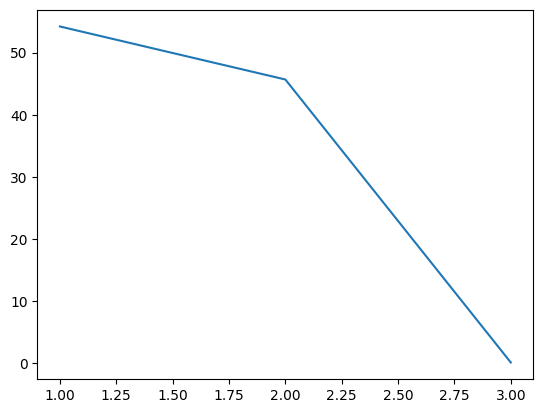

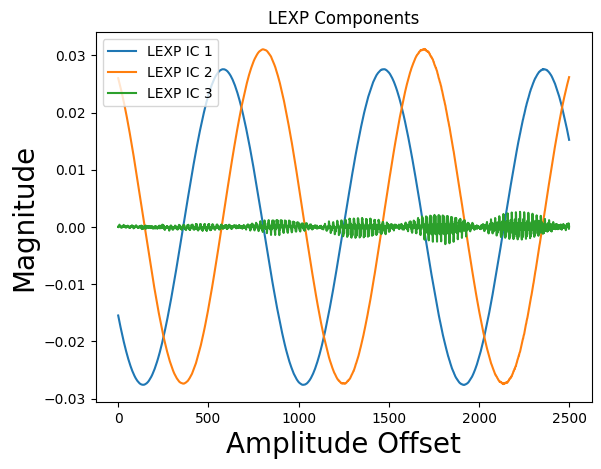

In [34]:
import matplotlib.pyplot as plt

clustScores = lexpPro.scores
clustComponents = lexpPro.outs
plt.figure()
plt.plot(range(1,len(clustScores)+1),clustScores)

txtsize = 20
plt.figure()
for i in range(len(clustScores)):
    plt.plot(clustComponents[i], label = "LEXP IC {}".format(i+1))
    plt.ylabel("Magnitude", size = txtsize)
    plt.xlabel("Amplitude Offset",size = txtsize)
plt.legend()
plt.title("LEXP Components")